# 04 — FC-TFI QRC on NARMA2 / NARMA10 + OTOC

Single-reservoir FC-TFI quantum reservoir (no classifier).

**Backends**
- `statevector` — pure unitary (ESP-less)
- `amplitude_damping` — `AerSimulator(method='density_matrix')` + local AD `NoiseModel`

**Encoding:** scalar $u_t$ → `RY` on `n_drive_qubits` only; hidden qubits have no direct drive.

**Pipeline order**
1. Run NARMA2/10 on **both** backends (store `J`, features, predictions)
2. Classical Ridge baseline on delay-embedded $u$
3. Sagawa-style OTOC + STM diagnostics on the **same** `J` / features from those runs

**OTOC:** Kutvonen, Fujii, Sagawa ([Sci. Rep. 2020](https://doi.org/10.1038/s41598-020-71673-9)) — average correlator of input-spin $Z$ with other spins; faster decay ↔ faster encoding / shorter but more accurate memory.


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import optuna
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, DensityMatrix, SparsePauliOp, Operator, SuperOp
from qiskit_aer.utils import insert_noise
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)
np.set_printoptions(precision=4, suppress=True)


In [40]:
# ── Config ───────────────────────────────────────────────────────────────────
# Both backends are always run for NARMA, then OTOC/STM use those artifacts.
# BACKEND kept only as a display default / optional single-run override elsewhere.
BACKEND = "statevector"

QRC_CONFIG = {
    "n_drive_qubits": 1,          # get RY(θ(u_t))
    "n_hidden_qubits": 5,         # FC-TFI only (no direct drive); need ≥1 for Sci.Rep. OTOC
    "num_layers_per_event": 2,
    "n_iterations": 3,            # resample J each iteration
    "random_seed": 42,
    "amplitude_damping_gamma": 1e-3,  # used only if BACKEND == amplitude_damping
    # Ising defaults (also used inside generate_ising_params)
    "J_std": 0.5,
    "h": 0.1,
    "t": 0.5,
    "n_trotter_steps": 3,
}

NARMA_CONFIG = {
    "T": 1200,          # total length
    "washout": 100,
    "train_frac": 0.7,  # of post-washout
    "val_frac": 0.15,
    "orders": (2, 10),
    "seed": 0,
}

OTOC_CONFIG = {
    "n_steps": 40,
    "w_qubit": 0,       # drive qubit (Z)
    "v_qubit": None,    # default: last qubit (X)
}

n_qubits = QRC_CONFIG["n_drive_qubits"] + QRC_CONFIG["n_hidden_qubits"]
assert QRC_CONFIG["n_drive_qubits"] >= 1
assert QRC_CONFIG["n_hidden_qubits"] >= 1, (
    "n_hidden_qubits must be ≥ 1: Sci. Rep. OTOC averages Z_drive against other spins."
)
assert QRC_CONFIG["n_drive_qubits"] + QRC_CONFIG["n_hidden_qubits"] == n_qubits
assert n_qubits >= 2

print("BACKEND:", BACKEND)
print("n_qubits:", n_qubits,
      f"(drive={QRC_CONFIG['n_drive_qubits']}, hidden={QRC_CONFIG['n_hidden_qubits']})")
print("QRC_CONFIG:", QRC_CONFIG)
print("NARMA_CONFIG:", NARMA_CONFIG)


BACKEND: statevector
n_qubits: 6 (drive=1, hidden=5)
QRC_CONFIG: {'n_drive_qubits': 1, 'n_hidden_qubits': 5, 'num_layers_per_event': 2, 'n_iterations': 3, 'random_seed': 42, 'amplitude_damping_gamma': 0.001, 'J_std': 0.5, 'h': 0.1, 't': 0.5, 'n_trotter_steps': 3}
NARMA_CONFIG: {'T': 1200, 'washout': 100, 'train_frac': 0.7, 'val_frac': 0.15, 'orders': (2, 10), 'seed': 0}


## NARMA data


In [41]:
# ── NARMA generator ──────────────────────────────────────────────────────────
def generate_narma(order, T, seed=0):
    """Standard NARMA-n with u ~ Uniform(0, 0.5)."""
    rng = np.random.default_rng(seed)
    u = rng.uniform(0.0, 0.5, size=T)
    y = np.zeros(T)
    for t in range(order, T):
        y[t] = (
            0.3 * y[t - 1]
            + 0.05 * y[t - 1] * np.sum(y[t - order:t])
            + 1.5 * u[t - order] * u[t]
            + 0.1
        )
    return u.astype(float), y.astype(float)


def chronological_splits(u, y, washout, train_frac, val_frac):
    u_w, y_w = u[washout:], y[washout:]
    n = len(y_w)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    slices = {
        "train": (u_w[:n_train], y_w[:n_train]),
        "val":   (u_w[n_train:n_train + n_val], y_w[n_train:n_train + n_val]),
        "test":  (u_w[n_train + n_val:], y_w[n_train + n_val:]),
    }
    return slices


def nmse(y_true, y_pred):
    """Normalized MSE: MSE / var(y_true)."""
    var = np.var(y_true)
    if var < 1e-15:
        return np.nan
    return float(mean_squared_error(y_true, y_pred) / var)


# Build datasets for each order
narma_data = {}
for order in NARMA_CONFIG["orders"]:
    u, y = generate_narma(order, NARMA_CONFIG["T"], seed=NARMA_CONFIG["seed"] + order)
    splits = chronological_splits(
        u, y,
        NARMA_CONFIG["washout"],
        NARMA_CONFIG["train_frac"],
        NARMA_CONFIG["val_frac"],
    )
    narma_data[order] = {"u": u, "y": y, "splits": splits}
    print(
        f"NARMA{order}: T={len(u)}, post-washout "
        f"train/val/test = "
        f"{len(splits['train'][1])}/{len(splits['val'][1])}/{len(splits['test'][1])}"
    )


NARMA2: T=1200, post-washout train/val/test = 770/165/165
NARMA10: T=1200, post-washout train/val/test = 770/165/165


## FC-TFI reservoir


In [42]:
# ── FC-TFI Hamiltonian + encoding ────────────────────────────────────────────
def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.1, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = rng.normal(0, J_std)
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def u_to_theta(u):
    """Map u in [0, 0.5] → θ in [0, π]."""
    return float(np.clip(u / 0.5, 0.0, 1.0) * np.pi)


def encode_drive(qc, theta, n_drive_qubits):
    for i in range(n_drive_qubits):
        qc.ry(theta, i)


def build_event_step_circuit(
    theta, ising_params, num_layers, n_qubits, n_drive_qubits, apply_initial_h,
    n_trotter_steps=3,
):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_drive(qc, theta, n_drive_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
        encode_drive(qc, theta, n_drive_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
    return qc


def pauli_string(n_qubits, basis, qubit):
    label = ['I'] * n_qubits
    label[n_qubits - 1 - qubit] = basis
    return ''.join(label)


def pauli_expectations(state, n_qubits):
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        for q in range(n_qubits):
            op = SparsePauliOp(pauli_string(n_qubits, basis, q))
            expectations[basis_idx * n_qubits + q] = state.expectation_value(op).real
    zz = np.zeros(n_qubits)
    for i in range(n_qubits):
        j = (i + 1) % n_qubits
        label = ['I'] * n_qubits
        label[n_qubits - 1 - i] = 'Z'
        label[n_qubits - 1 - j] = 'Z'
        op = SparsePauliOp(''.join(label))
        zz[i] = state.expectation_value(op).real
    return np.concatenate([expectations, zz])


In [ ]:
# ── Amplitude damping via AerSimulator + NoiseModel ──────────────────────────
def _ad_kraus(gamma):
    """Kraus ops for amplitude damping (legacy helper; OTOC now uses Aer SuperOp)."""
    s = np.sqrt(max(0.0, 1.0 - gamma))
    E0 = np.array([[1.0, 0.0], [0.0, s]], dtype=complex)
    E1 = np.array([[0.0, np.sqrt(max(0.0, gamma))], [0.0, 0.0]], dtype=complex)
    return E0, E1


def build_amplitude_damping_noise_model(gamma, n_qubits):
    """Local amplitude damping on every 1q/2q gate used by the FC-TFI step."""
    if gamma <= 0.0:
        return None
    nm = NoiseModel()
    err1 = amplitude_damping_error(gamma)
    # 1-qubit gates in encode + Trotter
    for gate in ("ry", "rx", "rz", "h", "id"):
        nm.add_all_qubit_quantum_error(err1, [gate])
    # 2-qubit: independent AD on each qubit after CX
    err2 = err1.tensor(err1)
    nm.add_all_qubit_quantum_error(err2, ["cx"])
    return nm


def make_aer_density_simulator(gamma, n_qubits, seed=42):
    nm = build_amplitude_damping_noise_model(gamma, n_qubits)
    kwargs = {"method": "density_matrix", "seed_simulator": seed}
    if nm is not None:
        kwargs["noise_model"] = nm
    return AerSimulator(**kwargs)


def aer_evolve_density_matrix(sim, rho, step_circuit, n_qubits):
    """One noisy step: load ρ, apply step under NoiseModel, save ρ'."""
    qc = QuantumCircuit(n_qubits)
    # Prefer Aer set/save density matrix instructions when available
    if hasattr(qc, "set_density_matrix"):
        qc.set_density_matrix(rho)
    else:
        from qiskit_aer.library import SetDensityMatrix
        qc.append(SetDensityMatrix(rho), range(n_qubits))
    qc.compose(step_circuit, inplace=True)
    if hasattr(qc, "save_density_matrix"):
        qc.save_density_matrix(label="rho")
    else:
        from qiskit_aer.library import SaveDensityMatrix
        qc.append(SaveDensityMatrix(n_qubits, label="rho"), range(n_qubits))

    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=1).result()
    data = result.data(0)
    rho_out = data["rho"]
    if not isinstance(rho_out, DensityMatrix):
        rho_out = DensityMatrix(rho_out)
    return rho_out


In [44]:
# ── Continuous reservoir runner ──────────────────────────────────────────────
def run_quantum_reservoir(
    u_series,
    ising_params,
    config,
    backend,
    initial_state=None,
    aer_sim=None,
):
    """Drive continuous FC-TFI with scalar u_t; return Pauli feature matrix + final state.

    Backends:
      - statevector: pure Statevector.evolve (no noise)
      - amplitude_damping: AerSimulator(method='density_matrix') + AD NoiseModel
    """
    n_drive = config["n_drive_qubits"]
    n_hid = config["n_hidden_qubits"]
    n_qubits = n_drive + n_hid
    num_layers = config["num_layers_per_event"]
    n_trotter = config.get("n_trotter_steps", 3)
    gamma = float(config.get("amplitude_damping_gamma", 0.0)) if backend == "amplitude_damping" else 0.0

    u_series = np.asarray(u_series, dtype=float).reshape(-1)
    m = len(u_series)
    n_obs = 4 * n_qubits
    H = np.zeros((m, n_obs))

    if backend == "statevector":
        state = Statevector.from_label("0" * n_qubits) if initial_state is None else initial_state
        sim = None
    elif backend == "amplitude_damping":
        state = DensityMatrix.from_label("0" * n_qubits) if initial_state is None else initial_state
        if not isinstance(state, DensityMatrix):
            state = DensityMatrix(state)
        sim = aer_sim or make_aer_density_simulator(
            gamma, n_qubits, seed=config.get("random_seed", 42)
        )
    else:
        raise ValueError(f"Unknown backend: {backend}")

    apply_h = initial_state is None
    for i, u in enumerate(u_series):
        theta = u_to_theta(u)
        step = build_event_step_circuit(
            theta, ising_params, num_layers, n_qubits, n_drive,
            apply_initial_h=apply_h,
            n_trotter_steps=n_trotter,
        )
        apply_h = False

        if backend == "statevector":
            state = state.evolve(step)
        else:
            state = aer_evolve_density_matrix(sim, state, step, n_qubits)

        H[i] = pauli_expectations(state, n_qubits)
        if i % 100 == 0:
            print(f"  sample {i+1}/{m}", end="\r")
    print()
    return H, state


## Ridge readout + NARMA experiments


In [45]:
# ── Ridge tuning / fit ───────────────────────────────────────────────────────
def fit_ridge_timeseries(H_train, y_train, H_val, y_val, seed=42, n_trials=30):
    def cv_mse(alpha):
        n = len(y_train)
        if n < 2:
            m = Ridge(alpha=alpha)
            m.fit(H_train, y_train)
            return float(mean_squared_error(y_train, m.predict(H_train)))
        n_folds = min(3, n - 1)
        tscv = TimeSeriesSplit(n_splits=n_folds)
        mses = []
        for tr, vl in tscv.split(H_train):
            m = Ridge(alpha=alpha)
            m.fit(H_train[tr], y_train[tr])
            mses.append(mean_squared_error(y_train[vl], m.predict(H_train[vl])))
        return float(np.mean(mses))

    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-4, 1e6, log=True)
        return cv_mse(alpha)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=n_trials)
    alpha = study.best_params["alpha"]
    model = Ridge(alpha=alpha)
    model.fit(H_train, y_train)
    val_pred = model.predict(H_val)
    return model, {
        "alpha": alpha,
        "val_nmse": nmse(y_val, val_pred),
        "val_mse": float(mean_squared_error(y_val, val_pred)),
    }


def run_narma_for_order(order, backend, config, n_qubits):
    splits = narma_data[order]["splits"]
    u_tr, y_tr = splits["train"]
    u_va, y_va = splits["val"]
    u_te, y_te = splits["test"]

    results = []
    preds = []
    # Keep last-iter reservoir artifacts for OTOC / STM (same J used in that iter)
    last_artifacts = None

    for it in range(config["n_iterations"]):
        print(f"\n=== NARMA{order} | {backend} | iter {it+1}/{config['n_iterations']} ===")
        rng = np.random.default_rng(config["random_seed"] + 17 * order + it)
        ising = generate_ising_params(
            n_qubits, rng,
            J_std=config["J_std"], h=config["h"], t=config["t"],
        )

        aer_sim = None
        if backend == "amplitude_damping":
            aer_sim = make_aer_density_simulator(
                float(config.get("amplitude_damping_gamma", 0.0)),
                n_qubits,
                seed=config["random_seed"] + it,
            )

        print("  reservoir train...")
        H_tr, st = run_quantum_reservoir(
            u_tr, ising, config, backend, aer_sim=aer_sim,
        )
        print("  reservoir val...")
        H_va, st = run_quantum_reservoir(
            u_va, ising, config, backend, initial_state=st, aer_sim=aer_sim,
        )
        print("  reservoir test...")
        H_te, st = run_quantum_reservoir(
            u_te, ising, config, backend, initial_state=st, aer_sim=aer_sim,
        )

        model, info = fit_ridge_timeseries(
            H_tr, y_tr, H_va, y_va,
            seed=config["random_seed"] + it,
        )
        yhat = model.predict(H_te)
        rec = {
            "iteration": it,
            "alpha": info["alpha"],
            "val_nmse": info["val_nmse"],
            "test_nmse": nmse(y_te, yhat),
            "test_rmse": float(np.sqrt(mean_squared_error(y_te, yhat))),
            "test_mae": float(mean_absolute_error(y_te, yhat)),
            "test_r2": float(r2_score(y_te, yhat)),
            "yhat": yhat,
            "ising": ising,
        }
        print(
            f"  alpha={rec['alpha']:.3g} | val NMSE={rec['val_nmse']:.4f} | "
            f"test NMSE={rec['test_nmse']:.4f} | test RMSE={rec['test_rmse']:.4f}"
        )
        results.append(rec)
        preds.append(yhat)
        last_artifacts = {
            "ising": ising,
            "H_train": H_tr,
            "u_train": np.asarray(u_tr, dtype=float),
            "H_val": H_va,
            "u_val": np.asarray(u_va, dtype=float),
            "H_test": H_te,
            "u_test": np.asarray(u_te, dtype=float),
            "backend": backend,
            "gamma": float(config.get("amplitude_damping_gamma", 0.0))
            if backend == "amplitude_damping"
            else 0.0,
        }

    ensemble = np.mean(np.stack(preds, axis=0), axis=0)
    summary = {
        "order": order,
        "backend": backend,
        "ensemble_nmse": nmse(y_te, ensemble),
        "ensemble_rmse": float(np.sqrt(mean_squared_error(y_te, ensemble))),
        "ensemble_r2": float(r2_score(y_te, ensemble)),
        "y_test": y_te,
        "yhat": ensemble,
        "results": results,
        "artifacts": last_artifacts,
    }
    print(
        f"\nEnsemble NARMA{order}/{backend}: "
        f"NMSE={summary['ensemble_nmse']:.4f} | RMSE={summary['ensemble_rmse']:.4f} | "
        f"R2={summary['ensemble_r2']:.4f}"
    )
    return summary


In [46]:
# ── Run NARMA on BOTH backends (required before OTOC / STM) ───────────────────
BACKENDS_TO_RUN = ("statevector", "amplitude_damping")

narma_summaries = {}  # key: (backend, order)
for backend in BACKENDS_TO_RUN:
    for order in NARMA_CONFIG["orders"]:
        narma_summaries[(backend, order)] = run_narma_for_order(
            order, backend, QRC_CONFIG, n_qubits
        )

print("\n======== NARMA Summary ========")
print(f"{'task':<10} {'backend':<20} {'NMSE':>10} {'RMSE':>10} {'R2':>10}")
for (backend, order), s in narma_summaries.items():
    print(
        f"NARMA{order:<4d} {backend:<20s} "
        f"{s['ensemble_nmse']:10.4f} {s['ensemble_rmse']:10.4f} {s['ensemble_r2']:10.4f}"
    )



=== NARMA2 | statevector | iter 1/3 ===
  reservoir train...
  sample 701/770
  reservoir val...
  sample 101/165
  reservoir test...
  sample 101/165
  alpha=20.1 | val NMSE=1.0425 | test NMSE=1.0586 | test RMSE=0.1119

=== NARMA2 | statevector | iter 2/3 ===
  reservoir train...
  sample 701/770
  reservoir val...
  sample 101/165
  reservoir test...
  sample 101/165
  alpha=23.4 | val NMSE=1.0584 | test NMSE=1.0692 | test RMSE=0.1124

=== NARMA2 | statevector | iter 3/3 ===
  reservoir train...
  sample 701/770
  reservoir val...
  sample 101/165
  reservoir test...
  sample 101/165
  alpha=9.78e+05 | val NMSE=1.0312 | test NMSE=1.0457 | test RMSE=0.1112

Ensemble NARMA2/statevector: NMSE=1.0545 | RMSE=0.1117 | R2=-0.0545

=== NARMA10 | statevector | iter 1/3 ===
  reservoir train...
  sample 701/770
  reservoir val...
  sample 101/165
  reservoir test...
  sample 101/165
  alpha=9.82e+05 | val NMSE=1.5682 | test NMSE=1.0056 | test RMSE=0.1239

=== NARMA10 | statevector | iter 2/3 

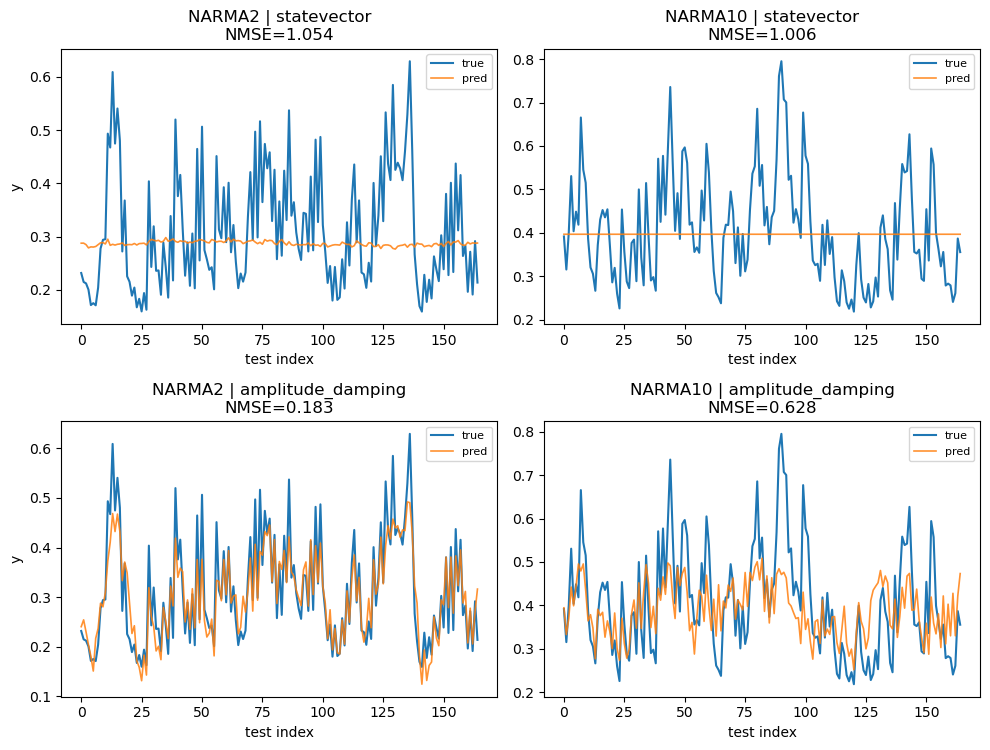

In [47]:
# ── Plot NARMA predictions (both backends) ───────────────────────────────────
orders = list(NARMA_CONFIG["orders"])
backends = list(BACKENDS_TO_RUN)
fig, axes = plt.subplots(len(backends), len(orders), figsize=(5 * len(orders), 3.8 * len(backends)), squeeze=False)
for r, backend in enumerate(backends):
    for c, order in enumerate(orders):
        s = narma_summaries[(backend, order)]
        ax = axes[r][c]
        ax.plot(s["y_test"], label="true", lw=1.5)
        ax.plot(s["yhat"], label="pred", lw=1.2, alpha=0.85)
        ax.set_title(f"NARMA{order} | {backend}\nNMSE={s['ensemble_nmse']:.3f}")
        ax.set_xlabel("test index")
        if c == 0:
            ax.set_ylabel("y")
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Classical Ridge baseline (no quantum reservoir)

Same Optuna + `TimeSeriesSplit` Ridge tuning as the QRC readout, but on a **classical delay embedding** of $u_t$:
$[u_t, u_{t-1}, \ldots, u_{t-L}]$ with $L=\max(10, \text{NARMA order})$.

This mirrors the classical baseline comparison in `03-FC-TFI-Ridge.ipynb` (linear readout on non-quantum features).


In [48]:
# ── Classical Ridge baseline on delay-embedded u ─────────────────────────────
def delay_embed(u, y, delay):
    """Build [u_t, u_{t-1}, ..., u_{t-delay}] aligned with y_t (drop first `delay` rows)."""
    u = np.asarray(u, dtype=float).reshape(-1)
    y = np.asarray(y, dtype=float).reshape(-1)
    T = len(u)
    X = np.column_stack([u[delay - d: T - d] for d in range(delay + 1)])
    return X, y[delay:]


def run_classical_ridge_narma(order, config_narma, seed=42, n_trials=30):
    splits = narma_data[order]["splits"]
    # Re-join chronological post-washout series from splits for consistent embedding,
    # then re-split with the same lengths.
    u = np.concatenate([splits["train"][0], splits["val"][0], splits["test"][0]])
    y = np.concatenate([splits["train"][1], splits["val"][1], splits["test"][1]])
    n_tr = len(splits["train"][1])
    n_va = len(splits["val"][1])

    delay = max(10, int(order))
    X_all, y_all = delay_embed(u, y, delay)

    # After embedding, first `delay` samples are dropped from the start of train
    # Adjust split boundaries on the embedded series:
    # original indices 0..n_tr-1 -> embedded starts at index `delay` of original
    # Keep val/test untouched in length by taking from the same chronological cut
    # relative to post-washout coordinates.
    # Embedded row k corresponds to original time t = k + delay.
    def slice_embedded(start, stop):
        # original [start:stop] -> embedded rows where t in [start, stop)
        # t = k + delay => k in [start-delay, stop-delay)
        a = max(0, start - delay)
        b = max(0, stop - delay)
        return X_all[a:b], y_all[a:b]

    X_tr, y_tr = slice_embedded(0, n_tr)
    X_va, y_va = slice_embedded(n_tr, n_tr + n_va)
    X_te, y_te = slice_embedded(n_tr + n_va, n_tr + n_va + len(splits["test"][1]))

    model, info = fit_ridge_timeseries(
        X_tr, y_tr, X_va, y_va, seed=seed, n_trials=n_trials,
    )
    yhat = model.predict(X_te)
    summary = {
        "order": order,
        "backend": "classical_ridge",
        "delay": delay,
        "alpha": info["alpha"],
        "val_nmse": info["val_nmse"],
        "ensemble_nmse": nmse(y_te, yhat),
        "ensemble_rmse": float(np.sqrt(mean_squared_error(y_te, yhat))),
        "ensemble_r2": float(r2_score(y_te, yhat)),
        "y_test": y_te,
        "yhat": yhat,
    }
    print(
        f"Classical Ridge NARMA{order}: delay={delay}, alpha={summary['alpha']:.3g} | "
        f"test NMSE={summary['ensemble_nmse']:.4f} | RMSE={summary['ensemble_rmse']:.4f} | "
        f"R2={summary['ensemble_r2']:.4f}"
    )
    return summary


classical_summaries = {}
for order in NARMA_CONFIG["orders"]:
    classical_summaries[order] = run_classical_ridge_narma(
        order, NARMA_CONFIG, seed=QRC_CONFIG["random_seed"], n_trials=30,
    )

print("\n======== Classical vs QRC ========")
print(f"{'task':<10} {'model':<22} {'NMSE':>10} {'RMSE':>10} {'R2':>10}")
for order in NARMA_CONFIG["orders"]:
    for backend in BACKENDS_TO_RUN:
        s = narma_summaries[(backend, order)]
        print(
            f"NARMA{order:<4d} {backend:<22s} "
            f"{s['ensemble_nmse']:10.4f} {s['ensemble_rmse']:10.4f} {s['ensemble_r2']:10.4f}"
        )
    s = classical_summaries[order]
    print(
        f"NARMA{order:<4d} {'classical_ridge':<22s} "
        f"{s['ensemble_nmse']:10.4f} {s['ensemble_rmse']:10.4f} {s['ensemble_r2']:10.4f}"
    )


Classical Ridge NARMA2: delay=10, alpha=0.000104 | test NMSE=0.1248 | RMSE=0.0384 | R2=0.8752
Classical Ridge NARMA10: delay=10, alpha=0.000104 | test NMSE=0.3504 | RMSE=0.0732 | R2=0.6496

======== Classical vs QRC ========
task       model                        NMSE       RMSE         R2
NARMA2    statevector                1.0545     0.1117    -0.0545
NARMA2    amplitude_damping          0.1829     0.0465     0.8171
NARMA2    classical_ridge            0.1248     0.0384     0.8752
NARMA10   statevector                1.0056     0.1239    -0.0056
NARMA10   amplitude_damping          0.6279     0.0979     0.3721
NARMA10   classical_ridge            0.3504     0.0732     0.6496


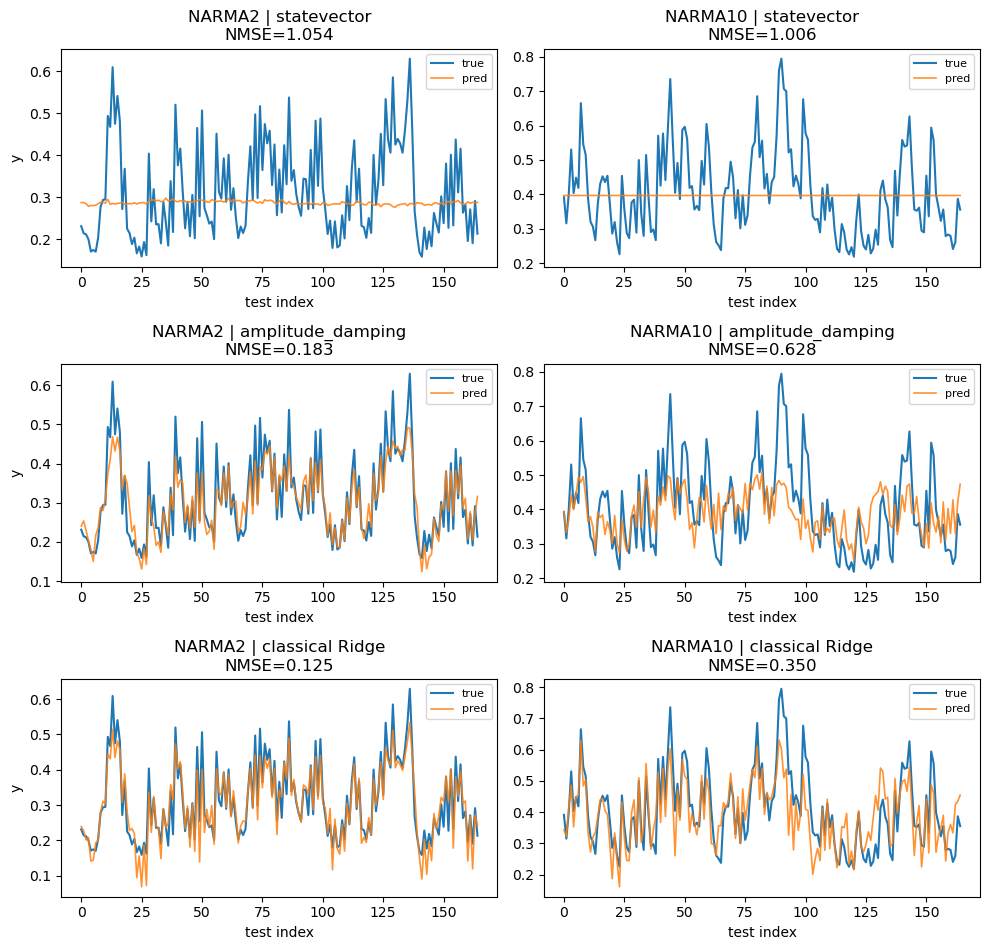

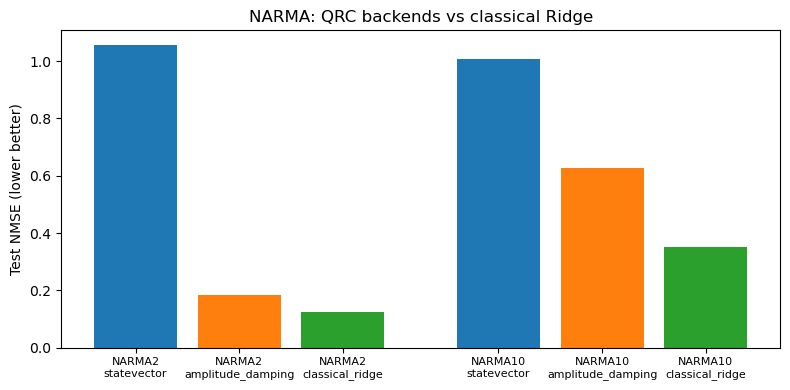

In [49]:
# ── Plot: QRC backends vs classical Ridge ────────────────────────────────────
orders = list(NARMA_CONFIG["orders"])
# rows: statevector, amplitude_damping, classical_ridge
row_keys = list(BACKENDS_TO_RUN) + ["classical_ridge"]
fig, axes = plt.subplots(
    len(row_keys), len(orders),
    figsize=(5 * len(orders), 3.2 * len(row_keys)),
    squeeze=False,
)
for r, key in enumerate(row_keys):
    for c, order in enumerate(orders):
        ax = axes[r][c]
        if key == "classical_ridge":
            s = classical_summaries[order]
            title_model = "classical Ridge"
        else:
            s = narma_summaries[(key, order)]
            title_model = key
        ax.plot(s["y_test"], label="true", lw=1.5)
        ax.plot(s["yhat"], label="pred", lw=1.2, alpha=0.85)
        ax.set_title(f"NARMA{order} | {title_model}\nNMSE={s['ensemble_nmse']:.3f}")
        ax.set_xlabel("test index")
        if c == 0:
            ax.set_ylabel("y")
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Compact bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels, vals, colors = [], [], []
color_map = {
    "statevector": "C0",
    "amplitude_damping": "C1",
    "classical_ridge": "C2",
}
x = 0
xticks, xticklabels = [], []
for order in orders:
    for key in row_keys:
        if key == "classical_ridge":
            nm = classical_summaries[order]["ensemble_nmse"]
        else:
            nm = narma_summaries[(key, order)]["ensemble_nmse"]
        labels.append(f"N{order}\n{key[:6]}")
        vals.append(nm)
        colors.append(color_map[key])
        xticks.append(x)
        xticklabels.append(f"N{order}\n{key.replace('_', '\n')}")
        x += 1
    x += 0.5  # gap between orders
ax.bar(xticks, vals, color=colors)
ax.set_xticks(xticks)
ax.set_xticklabels([f"NARMA{o}\n{k}" for o in orders for k in row_keys], fontsize=8)
ax.set_ylabel("Test NMSE (lower better)")
ax.set_title("NARMA: QRC backends vs classical Ridge")
fig.tight_layout()
plt.show()


## OTOC + STM (Sagawa / Sci. Rep. 2020)

Uses artifacts from the NARMA runs (same $J$, same train features).

**OTOC** ([Kutvonen, Fujii, Sagawa, Sci. Rep. 2020](https://doi.org/10.1038/s41598-020-71673-9), Eq. 9):
$$
O(t)=\frac{1}{N_s}\sum_{j\neq \mathrm{drive}}
\frac{1}{2^{N_s}}\mathrm{Re}\,\mathrm{Tr}\big[Z_{\mathrm{d}}(t_0)\,Z_j(t_0+t)\,Z_{\mathrm{d}}(t_0)\,Z_j(t_0+t)\big]
$$
- $Z_{\mathrm{d}}$ fixed at $t_0$; $Z_j$ Heisenberg-evolved under the FC-TFI step map (same $J$ as the NARMA run)
- Infinite-temperature normalization $\mathrm{Tr}(\cdot)/2^{N_s}$ (standard reading of their $\mathrm{Tr}$)
- Prefactor $1/N_s$ as in the paper (sum over other spins)
- **Interpretation:** faster $O(t)$ decay ⇒ faster encoding from the input spin into the others ⇒ shorter but more accurate STM memory; slower decay ⇒ longer but less accurate memory

**STM** (same paper): $R(d)=\mathrm{corr}^2(\hat u_{t-d}, u_{t-d})$, $\mathrm{MC}=\sum_d R(d)$ from reservoir features.

For the `amplitude_damping` backend, Heisenberg steps use the **same** `NoiseModel` + transpiled FC-TFI step as the reservoir (`insert_noise` → `SuperOp.adjoint()`), not a separate manual Kraus map.


In [ ]:
# ── OTOC utilities — Sagawa / Sci. Rep. 2020 (FC-TFI QRC) ────────────────────
def _embed_1q(op2, q, n_qubits):
    mats = [op2 if i == q else np.eye(2, dtype=complex) for i in range(n_qubits)]
    full = np.array([[1.0]], dtype=complex)
    for i in range(n_qubits - 1, -1, -1):
        full = np.kron(full, mats[i])
    return full


def build_otoc_step_circuit(ising_params, n_qubits, num_layers, n_trotter_steps):
    """One Ising scrambling step (no RY) — same Trotter content as reservoir layers."""
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=n_trotter_steps)
    return qc


def make_otoc_heisenberg_step(
    ising_params,
    n_qubits,
    num_layers,
    n_trotter_steps,
    backend,
    gamma=0.0,
    seed=42,
):
    """Return op -> Φ*(op) for one OTOC step, matching the reservoir backend.

    - statevector: unitary Heisenberg U† O U
    - amplitude_damping: same Aer NoiseModel as reservoir via insert_noise + SuperOp.adjoint()
      (channel identical to AerSimulator density_matrix + noise_model used in aer_evolve_density_matrix)
    """
    qc = build_otoc_step_circuit(ising_params, n_qubits, num_layers, n_trotter_steps)
    dim = 2 ** n_qubits

    if backend == "statevector" or float(gamma) <= 0.0:
        U = Operator(qc).data
        Udag = U.conj().T

        def step(op):
            return Udag @ op @ U

        return step, {"channel": "unitary"}

    if backend != "amplitude_damping":
        raise ValueError(f"Unknown backend for OTOC: {backend}")

    # Same simulator + NoiseModel construction as the reservoir runner
    nm = build_amplitude_damping_noise_model(gamma, n_qubits)
    sim = make_aer_density_simulator(gamma, n_qubits, seed=seed)
    tqc = transpile(qc, sim)
    print(
        f"  Building Aer noisy SuperOp for OTOC (n={n_qubits}, gamma={gamma}) "
        f"— same NoiseModel as reservoir; ~1–2 min on 6 qubits..."
    )
    noisy = insert_noise(tqc, nm)
    sop_adj = SuperOp(noisy).adjoint()
    S = np.asarray(sop_adj.data, dtype=complex)
    print(f"  Aer SuperOp ready: {S.shape}")

    def step(op):
        v = np.asarray(op, dtype=complex).reshape(-1, order="F")
        return (S @ v).reshape((dim, dim), order="F")

    return step, {"channel": "aer_noise_model", "gamma": float(gamma)}


def otoc_sagawa(
    ising_params,
    n_qubits,
    n_steps,
    drive_qubit,
    num_layers,
    n_trotter_steps,
    backend="statevector",
    gamma=0.0,
    seed=42,
):
    """Sagawa / Sci. Rep. 2020 Eq. 9 for FC-TFI QRC.

    O(t) = (1/N_s) Σ_{j ≠ drive} Re Tr[ Z_d(t0) Z_j(t0+t) Z_d(t0) Z_j(t0+t) ] / 2^{N_s}

    Z_d fixed at t0; each Z_j Heisenberg-evolved with a channel matching `backend`.
    """
    Ns = n_qubits
    d = 2 ** Ns
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    Zd = _embed_1q(Z, drive_qubit, Ns)

    targets = [q for q in range(Ns) if q != drive_qubit]
    if len(targets) == 0:
        raise ValueError(
            f"Sagawa OTOC needs ≥1 non-drive qubit; got n_qubits={Ns}, drive={drive_qubit}."
        )

    heisenberg_step, meta = make_otoc_heisenberg_step(
        ising_params, Ns, num_layers, n_trotter_steps,
        backend=backend, gamma=gamma, seed=seed,
    )
    print(f"  OTOC channel: {meta}")

    Zj_t = {q: _embed_1q(Z, q, Ns).copy() for q in targets}
    O = np.zeros(n_steps + 1)
    for t in range(n_steps + 1):
        acc = 0.0
        for q in targets:
            Zj = Zj_t[q]
            acc += np.trace(Zd @ Zj @ Zd @ Zj).real / d
        O[t] = acc / Ns

        for q in targets:
            Zj_t[q] = heisenberg_step(Zj_t[q])
    return O


def otoc_sagawa_stats(O):
    """Decay diagnostics matching Sagawa interpretation."""
    o0 = float(O[0])
    of = float(O[-1])
    half = 0.5 * (o0 + of)
    below = np.where(O <= half)[0]
    t_half = int(below[0]) if len(below) else None

    half0 = 0.5 * o0
    below0 = np.where(O <= half0)[0]
    t_half0 = int(below0[0]) if len(below0) else None

    k = min(5, len(O) - 1)
    early_slope = float((O[k] - O[0]) / k) if k > 0 else np.nan

    return {
        "O0": o0,
        "O_final": of,
        "t_half": t_half,
        "t_half0": t_half0,
        "early_slope": early_slope,
        "faster_decay": early_slope,
    }


In [ ]:
# ── STM memory capacity from stored reservoir features ───────────────────────
def stm_memory_curve(H, u, max_delay=50, alpha=1.0):
    """Short-term memory capacity curve R(d) and MC = Σ R(d).

    Target at time t is u[t-d]; features are H[t] (Kutvonen / Jaeger STM).
    """
    H = np.asarray(H, dtype=float)
    u = np.asarray(u, dtype=float).reshape(-1)
    assert len(H) == len(u)
    R = np.zeros(max_delay + 1)
    for d in range(1, max_delay + 1):
        if d >= len(u) - 2:
            break
        X = H[d:]
        y = u[:-d]
        # simple Ridge (fixed alpha)
        n_tr = int(0.7 * len(y))
        model = Ridge(alpha=alpha)
        model.fit(X[:n_tr], y[:n_tr])
        yhat = model.predict(X[n_tr:])
        yte = y[n_tr:]
        if np.var(yte) < 1e-15 or np.var(yhat) < 1e-15:
            R[d] = 0.0
        else:
            R[d] = float(np.corrcoef(yte, yhat)[0, 1] ** 2)
            if not np.isfinite(R[d]):
                R[d] = 0.0
    mc = float(np.sum(R[1:]))
    return R, mc


In [ ]:
# ── Sagawa OTOC + STM using NARMA-run artifacts ──────────────────────────────
ref_order = 10 if 10 in NARMA_CONFIG["orders"] else NARMA_CONFIG["orders"][0]

otoc_results = {}
stm_results = {}

for backend in BACKENDS_TO_RUN:
    art = narma_summaries[(backend, ref_order)]["artifacts"]
    ising = art["ising"]
    gamma = art["gamma"]
    print(f"\n--- Sagawa OTOC / STM for backend={backend} (NARMA{ref_order} J) ---")

    O = otoc_sagawa(
        ising,
        n_qubits,
        n_steps=OTOC_CONFIG["n_steps"],
        drive_qubit=OTOC_CONFIG["w_qubit"],
        num_layers=QRC_CONFIG["num_layers_per_event"],
        n_trotter_steps=QRC_CONFIG.get("n_trotter_steps", 3),
        backend=backend,
        gamma=gamma,
        seed=QRC_CONFIG["random_seed"],
    )
    stats = otoc_sagawa_stats(O)
    otoc_results[backend] = {"O": O, "stats": stats, "gamma": gamma}
    print("OTOC stats:", stats)
    print(
        "  (faster decay / more negative early_slope ⇒ faster encoding, "
        "shorter-but-more-accurate memory per Sagawa)"
    )

    R, mc = stm_memory_curve(
        art["H_train"], art["u_train"],
        max_delay=min(50, len(art["u_train"]) // 4),
        alpha=1.0,
    )
    stm_results[backend] = {"R": R, "MC": mc}
    print(f"STM memory capacity MC = {mc:.3f}")

# Plots: O(t) and R(d) only
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
for backend, rec in otoc_results.items():
    ax.plot(rec["O"], label=f"{backend}", lw=2)
ax.set_xlabel("step t")
ax.set_ylabel(r"$O(t)$ (Sagawa / Sci. Rep.)")
ax.set_title("OTOC decay — same J as NARMA run")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for backend, rec in stm_results.items():
    ax.plot(rec["R"][1:], label=f"{backend} (MC={rec['MC']:.2f})", lw=2)
ax.set_xlabel("delay d")
ax.set_ylabel(r"$R(d)$")
ax.set_title(f"STM capacity from NARMA{ref_order} features")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print("\n======== Sagawa memory-related summary ========")
print(
    f"{'backend':<20} {'O0':>8} {'O_final':>8} {'t_half':>8} {'t_half0':>8} "
    f"{'early_slope':>12} {'STM_MC':>8} {'NARMA_NMSE':>12}"
)
for backend in BACKENDS_TO_RUN:
    st = otoc_results[backend]["stats"]
    nm = narma_summaries[(backend, ref_order)]["ensemble_nmse"]
    print(
        f"{backend:<20} "
        f"{st['O0']:8.4f} {st['O_final']:8.4f} "
        f"{str(st['t_half']):>8} {str(st['t_half0']):>8} "
        f"{st['early_slope']:12.5f} "
        f"{stm_results[backend]['MC']:8.3f} {nm:12.4f}"
    )
